# Competing Risks Survival Analysis in R

## Overview

Competing risks arise when subjects can fail from multiple mutually exclusive causes. Standard KM and Cox PH treat all other causes as censoring — this is almost always wrong and leads to **overestimated** cumulative incidence.

**Two questions to distinguish:**

| Question | Method | R function |
|---|---|---|
| What is the absolute probability of failing from cause k by time t, accounting for competing risks? | **Cumulative incidence function (CIF)** | `cmprsk::cuminc()`, `tidycmprsk::cuminc()` |
| How do covariates affect the rate of failing from cause k, given competing risks? | **Fine-Gray subdistribution hazard model** | `cmprsk::crr()`, `tidycmprsk::crr()` |
| How do covariates affect the cause-specific hazard? | **Cause-specific Cox model** | Standard `coxph()` with events restricted to cause k |

**Why KM overestimates in the presence of competing risks:**  
KM treats deaths from other causes as censored, treating them as if they are still at risk for the event of interest. In reality, they have been permanently removed from the risk set. The CIF gives the correct probability.

## Applications by Sector

| Sector | Cause 1 | Cause 2 |
|---|---|---|
| **Ecology** | Colonisation by target species | Patch destroyed before colonisation |
| **Healthcare** | Death from cancer | Death from other causes |
| **Finance** | Loan default | Early repayment |
| **Insurance** | Claim filed | Policy lapse or cancellation |

---

## Setup

In [1]:
library(tidyverse)
library(survival)    # Surv(), survfit() — cause-specific
library(cmprsk)      # cuminc(), crr() — CIF and Fine-Gray
library(tidycmprsk)  # tidy wrappers for cmprsk
library(ggplot2)
library(broom)

set.seed(42)

# ── Simulate competing risks: colonisation vs. patch destruction ───────────────
# Event types: 0 = censored, 1 = colonised (event of interest), 2 = patch destroyed
n <- 300
cr_data <- tibble(
  id      = 1:n,
  habitat = factor(sample(c("reference","restored","degraded"), n,
                          replace=TRUE, prob=c(0.35,0.35,0.30)),
                   levels=c("reference","restored","degraded")),
  # Colonisation times (cause 1)
  t1      = rexp(n, rate=case_when(
                  habitat=="reference" ~ 0.10,
                  habitat=="restored"  ~ 0.06,
                  habitat=="degraded"  ~ 0.03)),
  # Patch destruction times (cause 2) — higher in degraded habitat
  t2      = rexp(n, rate=case_when(
                  habitat=="reference" ~ 0.02,
                  habitat=="restored"  ~ 0.03,
                  habitat=="degraded"  ~ 0.07)),
  # Study end at day 40
  t_admin = 40
) %>%
  mutate(
    # Observed time = first of any event or administrative censoring
    time   = pmin(t1, t2, t_admin),
    # Event status: 0=censored, 1=colonised, 2=destroyed
    status = case_when(
               t1 < t2 & t1 <= t_admin ~ 1L,
               t2 < t1 & t2 <= t_admin ~ 2L,
               TRUE                    ~ 0L
             )
  )

count(cr_data, status,
      label=c(`0`="censored",`1`="colonised",`2`="destroyed")[as.character(status)])

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'survival' was built under R version 4.4.3"
Warning message:
"package 'cmprsk' was built under R version 4.

status,label,n
<int>,<chr>,<int>
0,censored,10
1,colonised,173
2,destroyed,117


---

## Why KM Overestimates: A Demonstration

In [2]:
# ── Naive KM: treat competing events as censoring (WRONG) ─────────────────────
km_naive <- survfit(
  Surv(time, status == 1) ~ habitat,   # coding cause 2 as censored
  data = cr_data
)

# ── Correct: cause-specific KM (event = cause 1 only) ─────────────────────────
# This is identical to above for the KM estimate — same formula
# The difference comes in interpretation and when computing CIF (next section)

# ── CIF via cmprsk ────────────────────────────────────────────────────────────
cif <- cmprsk::cuminc(
  ftime  = cr_data$time,
  fstatus = cr_data$status,
  group  = cr_data$habitat,
  cencode = 0
)
# Returns CIF estimates for each cause × group combination

# ── Compare: 1 - KM vs. CIF for colonisation at day 30 ───────────────────────
km_tidy_naive <- broom::tidy(km_naive) %>%
  mutate(habitat=str_remove(strata,"habitat="),
         km_cum_inc = 1 - estimate)   # 1-KM treated as cumulative incidence

# CIF tidy
cif_tidy <- tidycmprsk::cuminc(
  Surv(time, factor(status)) ~ habitat,
  data = cr_data
) %>% tidy(times=30) %>% filter(outcome=="1")

cat("At day 30: Naive 1-KM vs. Correct CIF for cause 1 (colonisation):\n")
km_tidy_naive %>% filter(time==max(time[time<=30])) %>%
  select(habitat, km_cum_inc) %>%
  left_join(cif_tidy %>% select(strata, estimate) %>%
            rename(habitat=strata, cif=estimate), by="habitat") %>%
  mutate(overestimate = round(km_cum_inc - cif, 4)) %>%
  print()
# 1-KM always >= CIF; the gap is the "borrowed" probability from competing events

At day 30: Naive 1-KM vs. Correct CIF for cause 1 (colonisation):
# A tibble: 1 × 4
  habitat  km_cum_inc   cif overestimate
  <chr>         <dbl> <dbl>        <dbl>
1 restored      0.834 0.648        0.186


---

## Plotting the Cumulative Incidence Function

Warning message:
"Removed 56 rows containing missing values or values outside the scale range
(`geom_ribbon()`)."


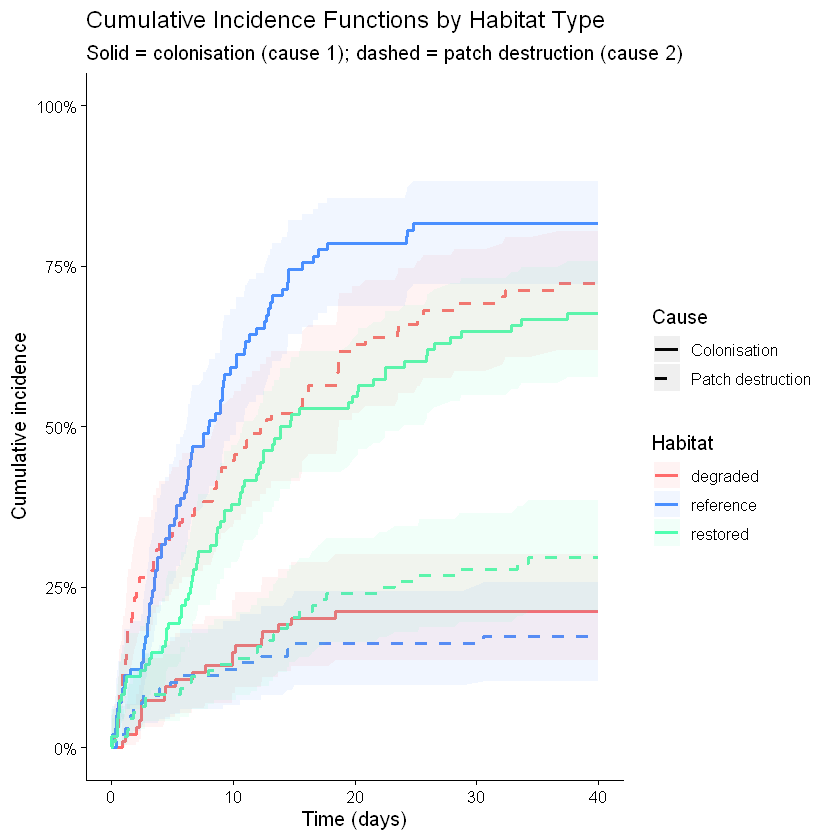

In [3]:
# tidycmprsk CIF with ggplot2
cif_fit <- tidycmprsk::cuminc(
  Surv(time, factor(status)) ~ habitat,
  data = cr_data
)

# Plot both causes stacked
ggcuminc_data <- broom::tidy(cif_fit) %>%
  mutate(
    habitat = str_remove(strata, "habitat="),
    cause   = factor(outcome, labels=c("Colonisation","Patch destruction"))
  )

pal_habitat <- c(reference="#4a8fff", restored="#4fffb0", degraded="#ff6b6b")

ggplot(ggcuminc_data,
       aes(x=time, y=estimate, color=habitat, linetype=cause)) +
  geom_step(linewidth=0.9) +
  geom_ribbon(aes(ymin=conf.low, ymax=conf.high, fill=habitat),
              alpha=0.08, color=NA) +
  scale_color_manual(values=pal_habitat) +
  scale_fill_manual(values=pal_habitat) +
  scale_linetype_manual(values=c("solid","dashed")) +
  scale_y_continuous(limits=c(0,1), labels=scales::percent) +
  labs(title    = "Cumulative Incidence Functions by Habitat Type",
       subtitle  = "Solid = colonisation (cause 1); dashed = patch destruction (cause 2)",
       x = "Time (days)", y = "Cumulative incidence",
       color="Habitat", fill="Habitat", linetype="Cause") +
  theme_classic(base_size=12)

---

## Fine-Gray Subdistribution Hazard Model

In [4]:
# Fine-Gray models the subdistribution hazard for cause k
# Effect of covariates on the CIF directly
# Subjects who fail from competing causes remain in the risk set (with weight 0)

# ── crr() from cmprsk ─────────────────────────────────────────────────────────
# Must supply a numeric covariate matrix
cov_mat <- model.matrix(
  ~ habitat + 0,   # 0 removes intercept; creates habitat dummies
  data=cr_data
)[, -1]   # drop reference level

fg_fit <- cmprsk::crr(
  ftime   = cr_data$time,
  fstatus = cr_data$status,
  cov1    = cov_mat,
  failcode = 1,    # cause of interest
  cencode  = 0
)
summary(fg_fit)
# exp(coef): subdistribution hazard ratio (SHR)
# SHR > 1: covariate increases the CIF (faster accumulation)
# SHR < 1: covariate decreases the CIF (protective)

# ── tidycmprsk tidy wrapper ───────────────────────────────────────────────────
fg_tidy <- tidycmprsk::crr(
  Surv(time, factor(status)) ~ habitat,
  data     = cr_data,
  failcode = 1
)
tidy(fg_tidy, exponentiate=TRUE, conf.int=TRUE)

Competing Risks Regression

Call:
cmprsk::crr(ftime = cr_data$time, fstatus = cr_data$status, cov1 = cov_mat, 
    failcode = 1, cencode = 0)

                  coef exp(coef) se(coef)     z p-value
habitatrestored -0.499     0.607    0.160 -3.12 1.8e-03
habitatdegraded -1.953     0.142    0.264 -7.39 1.4e-13

                exp(coef) exp(-coef)   2.5% 97.5%
habitatrestored     0.607       1.65 0.4440 0.831
habitatdegraded     0.142       7.05 0.0846 0.238

Num. cases = 300
Pseudo Log-likelihood = -882 
Pseudo likelihood ratio test = 81.7  on 2 df,

term,estimate,std.error,statistic,conf.low,conf.high,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
habitatrestored,0.6073001,0.1597613,-3.121734,0.4440320,0.8306009,1.8e-03
habitatdegraded,0.1418929,0.2641514,-7.392284,0.0845502,0.2381260,1.4e-13


---

## Cause-Specific Hazard Models

In [8]:
# Cause-specific Cox: restrict events to one cause; treat others as censoring
# Estimates the hazard of cause k among subjects still at risk of any cause

# Cause 1 model (colonisation)
cs1 <- coxph(
  Surv(time, status == 1) ~ habitat,
  data = cr_data
)

# Cause 2 model (patch destruction)
cs2 <- coxph(
  Surv(time, status == 2) ~ habitat,
  data = cr_data
)

# ── Compare Fine-Gray SHR vs. Cause-specific HR ───────────────────────────────
tibble(
  term   = c("habitatrestored", "habitatdegraded"),
  CS_HR  = round(exp(coef(cs1)[c("habitatrestored", "habitatdegraded")]), 3),
  FG_SHR = round(exp(fg_tidy$tidy$estimate[fg_tidy$tidy$term %in%
                       c("habitatrestored", "habitatdegraded")]), 3)
) %>%
  mutate(interpretation = c(
    "Restored vs. reference: cause-specific rate and CIF effect",
    "Degraded vs. reference: cause-specific rate and CIF effect"
  )) %>% print()

# Key distinction:
# Cause-specific HR: effect on the instantaneous rate of cause k
#                    among those who haven't failed from any cause yet
# Fine-Gray SHR:    effect on the CIF — the absolute probability of
#                    failing from cause k, accounting for competing risks
# They can point in different directions when competing risks are strong

# A tibble: 2 × 4
  term            CS_HR FG_SHR interpretation                                   
  <chr>           <dbl>  <dbl> <chr>                                            
1 habitatrestored 0.517  0.607 Restored vs. reference: cause-specific rate and …
2 habitatdegraded 0.186  0.142 Degraded vs. reference: cause-specific rate and …


---

## Reporting Results

In [9]:
# Standard format:
# "Competing risks analysis was performed using cumulative incidence
#  functions (Gray's test) and Fine-Gray subdistribution hazard models
#  (Fine & Gray 1999). Patch destruction was treated as a competing risk
#  for colonisation. At 30 days, the cumulative incidence of colonisation
#  was XX% (95% CI: XX-XX%) for reference sites, XX% for restored, and
#  XX% for degraded sites. These values are lower than naive 1-KM
#  estimates of XX%, XX%, and XX% respectively, demonstrating the
#  upward bias of KM in the presence of competing risks.
#
#  Fine-Gray models indicated that degraded habitat was associated with
#  a significantly lower subdistribution hazard of colonisation
#  (SHR=X.X, 95% CI [X.X, X.X], p=.XXX), after accounting for the
#  competing risk of patch destruction."
cat("Reporting guidance above.\n")

Reporting guidance above.


---

## Common Pitfalls

**1. Treating competing events as censoring in KM**  
This is the most widespread error in survival analysis with multiple failure causes. It always produces an upwardly biased cumulative incidence estimate. Use `cuminc()` for absolute risk estimation whenever competing risks are present.

**2. Confusing cause-specific HRs and Fine-Gray SHRs**  
These answer different questions. Cause-specific HR: mechanistic — what is the rate of cause k conditional on being event-free? Fine-Gray SHR: prognostic — what is the absolute risk of cause k over time? For clinical decision-making and absolute risk prediction, Fine-Gray is preferred. For aetiological questions, cause-specific models are more appropriate.

**3. Reporting only the event of interest without showing the competing risk**  
Always show CIFs for all competing causes simultaneously. A very high competing risk can make the event of interest appear rare not because it is truly rare but because subjects are failing from other causes first.

**4. Checking proportional hazards only for the cause of interest**  
In Fine-Gray models, the subdistribution proportional hazards assumption should be checked for all covariates. Use `crr()` residuals or plot the log(-log(1-CIF)) vs. log(time) for categorical variables.

**5. Using competing risks analysis without a clear pre-specified primary cause**  
Competing risks analysis requires deciding a priori which cause is primary and which are competing. Post-hoc selection of the cause that produces the most significant result is a form of p-hacking.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*